# 01 — Trust-Aware SAE Alarm Controller: Corrected Synthetic Validation

**Purpose:** validate the mechanism before moving to MIMIC.

This notebook implements the guide's synthetic proof-of-concept, but fixes three experimental issues:
1. Stage-1 calibration uses a separate validation split.
2. The fixed-penalty ablation explicitly separates **no-trust-state** from **trust-state**.
3. The matched threshold is selected on validation and evaluated once on held-out test.

**Important:** synthetic results are mechanism validation only, not clinical validation.


In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

from sae_core import (
    Config, simulate_cohort, make_labels, split_patients,
    RiskForecaster, evaluate_all
)

cfg = Config(seed=42)
print(cfg)


Config(horizon=6, n_features=5, event_rate=0.35, min_T=24, max_T=60, trust_dec_fa=0.28, trust_rec=0.015, trust_rec_true=0.04, act_floor=0.05, r_hit=3.0, r_fa=1.0, r_miss=2.0, r_tn=0.05, wait_cost=0.0, gamma=0.98, kappa=0.5, ignored_true_fraction=0.15, fqi_iters=15, n_trees=80, min_samples_leaf=8, seed=42, feature_weights=(1.0, 0.8, 0.6, 1.2, 0.9))


In [2]:
# Generate a synthetic cohort.
rng = np.random.default_rng(42)
patients = make_labels(
    simulate_cohort(
        n_patients=900,
        cfg=cfg,
        rng=rng,
        noise=1.05,
        ramp_mag=2.0,
    ),
    cfg,
)

train, val, test = split_patients(patients, train_frac=0.60, val_frac=0.20, seed=42)

def describe(name, cohort):
    n = len(cohort)
    events = sum(p["tau"] is not None for p in cohort)
    hours = sum(p["T"] for p in cohort)
    positive_hours = sum(int(p["y"].sum()) for p in cohort)
    print(f"{name}: patients={n}, events={events}, hours={hours}, positive_hours={positive_hours}")

describe("TRAIN", train)
describe("VALIDATION", val)
describe("TEST", test)


TRAIN: patients=540, events=181, hours=23138, positive_hours=1086
VALIDATION: patients=180, events=67, hours=7526, positive_hours=402
TEST: patients=180, events=74, hours=7348, positive_hours=444


In [3]:
# Stage 1: fit on TRAIN, calibrate on VALIDATION.
forecaster = RiskForecaster(cfg).fit(train, val)

train_metrics = forecaster.evaluate(train)
val_metrics = forecaster.evaluate(val)
test_metrics = forecaster.evaluate(test)

print("Stage-1 metrics")
print(pd.DataFrame([train_metrics, val_metrics, test_metrics], index=["train","validation","test"]).round(4))


Stage-1 metrics
             AUROC   AUPRC  positive_rate
train       0.9279  0.6018         0.0469
validation  0.8894  0.5087         0.0534
test        0.8800  0.5002         0.0604


In [4]:
# Stage 2: explicit ablation + trust-aware controller.
results, controllers = evaluate_all(
    train=train,
    val=val,
    test=test,
    forecaster=forecaster,
    cfg=cfg,
    seed=42,
)

results_df = pd.DataFrame(results)
display(results_df.round(4))


,event_sens_raised,event_sens_acted,median_lead,false_alarms_per_100h,alarms_per_100h,mean_trust,events,total_hours,method,seed,threshold,validation_alarm_burden
0,0.7432,0.0270,3.5,0.9118,1.6603,0.0758,74,7348,naive,42,NaN,NaN
1,0.9054,0.6892,3.0,0.1633,1.0751,0.7132,74,7348,fixed_no_trust,42,NaN,NaN
2,0.8108,0.1486,3.0,0.5035,1.3201,0.1875,74,7348,fixed_with_trust,42,NaN,NaN
3,0.8784,0.7568,3.0,0.1361,1.0207,0.8287,74,7348,trust_aware,42,NaN,NaN
4,0.9054,0.6486,3.0,0.1769,1.0887,0.6947,74,7348,threshold_matched,42,0.45,0.9567


In [5]:
# Compare the key metrics.
cols = [
    "method", "event_sens_raised", "event_sens_acted",
    "median_lead", "false_alarms_per_100h",
    "alarms_per_100h", "mean_trust"
]
display(results_df[cols].sort_values("event_sens_acted", ascending=False).round(4))


,method,event_sens_raised,event_sens_acted,median_lead,false_alarms_per_100h,alarms_per_100h,mean_trust
3,trust_aware,0.8784,0.7568,3.0,0.1361,1.0207,0.8287
1,fixed_no_trust,0.9054,0.6892,3.0,0.1633,1.0751,0.7132
4,threshold_matched,0.9054,0.6486,3.0,0.1769,1.0887,0.6947
2,fixed_with_trust,0.8108,0.1486,3.0,0.5035,1.3201,0.1875
0,naive,0.7432,0.0270,3.5,0.9118,1.6603,0.0758


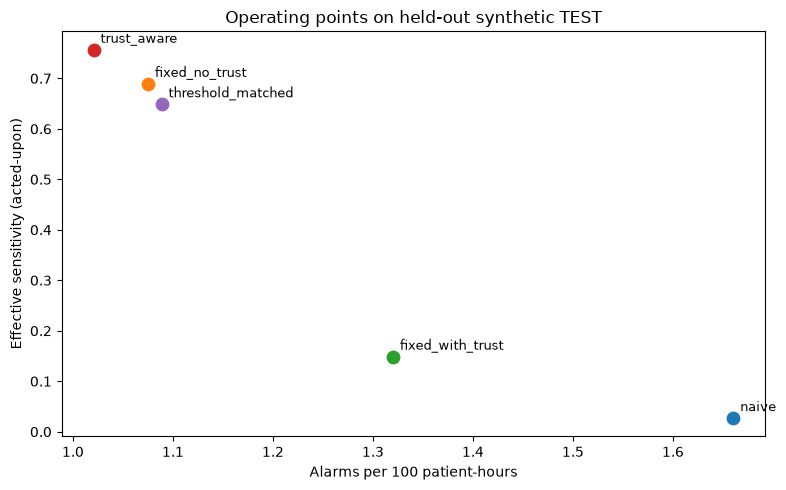

In [6]:
# Plot effective detection vs alarm burden.
fig, ax = plt.subplots(figsize=(8, 5))
for _, r in results_df.iterrows():
    ax.scatter(r["alarms_per_100h"], r["event_sens_acted"], s=80)
    ax.annotate(r["method"], (r["alarms_per_100h"], r["event_sens_acted"]),
                xytext=(5,5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Alarms per 100 patient-hours")
ax.set_ylabel("Effective sensitivity (acted-upon)")
ax.set_title("Operating points on held-out synthetic TEST")
plt.tight_layout()
plt.show()


## Interpretation

The main ablation is:

- `fixed_no_trust`: fixed reward, no trust in state
- `fixed_with_trust`: fixed reward, trust in state
- `trust_aware`: trust in state + trust-derived reward

This isolates whether any gain comes merely from giving FQI the trust variable, or from the **trust-aware reward mechanism itself**.
